In [2]:
import matplotlib.pyplot as plt
from itertools import product
import igraph as ig
import numpy as np

%matplotlib inline

```
     F -- G -- H
    /      \\ /
   D         E
 /  \\      /
A -- B -- C
```

In [3]:
class KagomeLattice:
    def __init__(self, width=1, height=1):
        theta = np.pi / 3
        u = np.array([1, 0])
        v = np.array([np.cos(theta), np.sin(theta)])

        self.lattice_basis = np.c_[u, v]

        named_sites = {
            "A": np.array([0, 0]),
            "B": np.array([1, 0]),
            "C": np.array([2, 0]),
            "D": np.array([0, 1]),
            "E": np.array([2, 1]),
            "F": np.array([0, 2]),
            "G": np.array([1, 2]),
            "H": np.array([2, 2]),
        }

        named_edges = [
            ("AB", 1),
            ("BC", 1),
            ("AD", 1),
            ("BD", 2),
            ("DF", 1),
            ("FG", 1),
            ("GE", 2),
            ("GH", 1),
            ("EH", 1),
            ("CE", 1),
        ]

        edges = [
            ((named_sites[start], named_sites[end]), kind)
            for (start, end), kind in named_edges
        ]

        sites = []
        self.edges = []

        for i, j in product(range(width), range(height)):
            shift = 2 * np.array([i, j])
            for site in named_sites.values():
                sites.append(site + shift)
            for (start, end), kind in edges:
                self.edges.append(
                    (
                        (start + shift, end + shift),
                        kind,
                    )
                )

        self.site_to_num = {}
        new_num = 0
        for site in sites:
            canonical_coords = tuple(site % (2 * np.array([width, height])))
            if canonical_coords in self.site_to_num:
                self.site_to_num[tuple(site)] = self.site_to_num[canonical_coords]
            else:
                self.site_to_num[canonical_coords] = new_num
                self.site_to_num[tuple(site)] = new_num
                new_num += 1

        self.abstract_edges_to_kind = {}
        for (start, end), kind in self.edges:
            self.abstract_edges_to_kind[
                (self.site_to_num[tuple(start)], self.site_to_num[tuple(end)])
            ] = kind
    def as_igraph(self):
        edges, kinds = zip(*self.abstract_edges_to_kind.items())
        return ig.Graph(edges=edges, edge_attrs={'kind': kinds})
                        
    def plot(self):
        for site, num in self.site_to_num.items():
            plt.plot(*(self.lattice_basis @ site), "o", color="C0")
            plt.annotate(str(num), self.lattice_basis @ site)
            
        for (start, end), kind in self.edges:
            plt.plot(
                *zip(self.lattice_basis @ start, self.lattice_basis @ end),
                color=f"C{kind}",
            )

lat.site_to_num.values()=dict_values([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 10, 11, 12, 13, 14, 15, 10, 11, 16, 17, 18, 19, 20, 21, 16, 17, 22, 0, 3, 23, 5, 8, 22, 0])
lat.abstract_edges_to_kind={(0, 1): 1, (1, 2): 1, (0, 3): 1, (1, 3): 2, (3, 5): 1, (5, 6): 1, (6, 4): 2, (6, 7): 1, (4, 7): 1, (2, 4): 1, (5, 8): 1, (6, 8): 2, (8, 0): 1, (1, 9): 2, (9, 2): 1, (7, 9): 1, (2, 10): 1, (10, 11): 1, (10, 4): 2, (7, 13): 1, (13, 12): 2, (13, 14): 1, (12, 14): 1, (11, 12): 1, (13, 9): 2, (10, 15): 2, (15, 11): 1, (14, 15): 1, (11, 16): 1, (16, 17): 1, (16, 12): 2, (14, 19): 1, (19, 18): 2, (19, 20): 1, (18, 20): 1, (17, 18): 1, (19, 15): 2, (16, 21): 2, (21, 17): 1, (20, 21): 1, (17, 22): 1, (22, 0): 1, (22, 18): 2, (20, 23): 1, (23, 3): 2, (23, 5): 1, (23, 21): 2, (22, 8): 2}


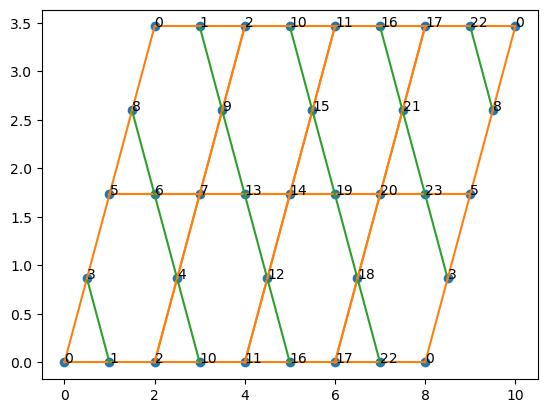

In [4]:
lat = KagomeLattice(width=4, height=2)
lat.plot()
assert sorted(set(lat.site_to_num.values())) == list(range(24))
print(f"{lat.site_to_num.values()=}")
print(f"{lat.abstract_edges_to_kind=}")

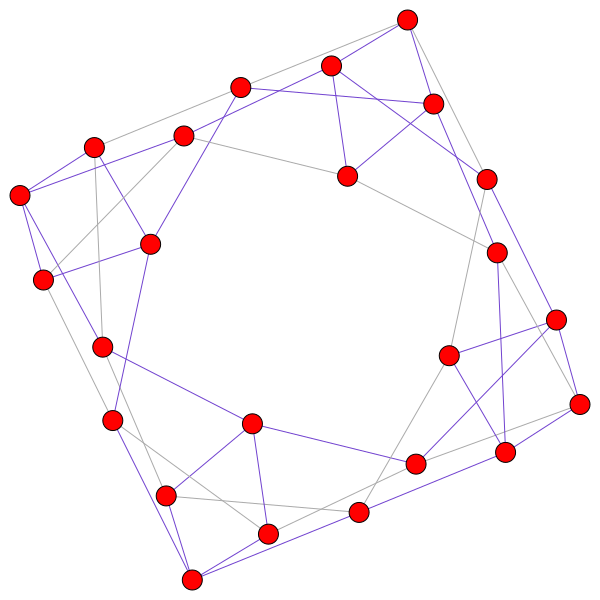

In [6]:
g = lat.as_igraph()
ig.plot(g, edge_color=["#7142cf" if kind == 1 else "#AAA" for kind in g.es["kind"]])

In [7]:
g.get_automorphisms_vf2(edge_color=g.es['kind'])

[[0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23],
 [0,
  22,
  17,
  8,
  21,
  5,
  23,
  20,
  3,
  18,
  16,
  11,
  15,
  19,
  14,
  12,
  10,
  2,
  9,
  13,
  7,
  4,
  1,
  6],
 [2,
  1,
  0,
  9,
  8,
  7,
  6,
  5,
  4,
  3,
  22,
  17,
  21,
  23,
  20,
  18,
  16,
  11,
  15,
  19,
  14,
  12,
  10,
  13],
 [2,
  10,
  11,
  4,
  12,
  7,
  13,
  14,
  9,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  0,
  3,
  23,
  5,
  8,
  1,
  6],
 [5,
  6,
  7,
  8,
  9,
  0,
  1,
  2,
  3,
  4,
  13,
  14,
  15,
  10,
  11,
  12,
  19,
  20,
  21,
  16,
  17,
  18,
  23,
  22],
 [5,
  23,
  20,
  3,
  18,
  0,
  22,
  17,
  8,
  21,
  19,
  14,
  12,
  16,
  11,
  15,
  13,
  7,
  4,
  10,
  2,
  9,
  6,
  1],
 [7,
  6,
  5,
  4,
  3,
  2,
  1,
  0,
  9,
  8,
  23,
  20,
  18,
  22,
  17,
  21,
  19,
  14,
  12,
  16,
  11,
  15,
  13,
  10],
 [7,
  13,
  14,
  9,
  15,
  2,
  10,
  11,
  4,
  12,

In [ ]:
import numpy as np
import scipy.sparse.linalg

import lattice_symmetries as ls

number_spins = 24  # System size
hamming_weight = number_spins // 2  # Hamming weight (i.e. number of spin ups)

# Constructing symmetries


symmetries = []
sites = np.arange(number_spins)


# Momentum in x direction with eigenvalue π
T = (sites + 1) % number_spins

# for number_spins == 12, sector = 0, spin_inversion = 1

symmetries.append(ls.Symmetry(T, sector=number_spins // 2))
# Parity with eigenvalue π
P = sites[::-1]
symmetries.append(ls.Symmetry(P, sector=1))

# Constructing the group
symmetry_group = ls.Group(symmetries)
print("Symmetry group contains {} elements".format(len(symmetry_group)))

# Constructing the basis
basis = ls.SpinBasis(
    symmetry_group,
    number_spins=number_spins,
    hamming_weight=hamming_weight,
    spin_inversion=-1,
)
basis.build()  # Build the list of representatives, we need it since we're doing ED
print("Hilbert space dimension is {}".format(basis.number_states))

# Heisenberg Hamiltonian
# fmt: off
σ_x = np.array([ [0, 1]
               , [1, 0] ])
σ_y = np.array([ [0 , -1j]
               , [1j,   0] ])
σ_z = np.array([ [1,  0]
               , [0, -1] ])
# fmt: on
σ_p = σ_x + 1j * σ_y
σ_m = σ_x - 1j * σ_y

matrix = 0.5 * (np.kron(σ_p, σ_m) + np.kron(σ_m, σ_p)) + np.kron(σ_z, σ_z)
edges = [(i, (i + 1) % number_spins) for i in range(number_spins)]
hamiltonian = ls.Operator(basis, [ls.Interaction(matrix, edges)])

# Diagonalize the Hamiltonian using ARPACK
eigenvalues, eigenstates = ls.diagonalize(hamiltonian, k=2)
print("Ground state energy is {:.10f}".format(eigenvalues[0]))
# assert np.isclose(eigenvalues[0], -18.06178542)